# Регрессия глубины дефектов

Оценка глубины залегания дефекта (мм) по ИК-видео. Обучаемся на дефектных кропах;
локализацию на инференсе даёт сегментация.

**Инфраструктура — общая:** `TermoDataset` + `datasets.transforms` (TSR → per-crop
`PerChannelZNorm` → `AppendDerivatives`). Таргет — сырые мм, нормировка входа
per-instance → веса самодостаточны (тот же препроцессинг, что в `pipeline`).
Приватный модуль `experiments/regression` не используется.

**Диапазоны глубин почти не пересекаются:** kaggle 5–25 мм (5 дискретных уровней),
tpu 0.5–6.1 мм (непрерывно) — отсюда сценарии переноса и смешивания.

Метрики (в мм): `mae_mm`, `rmse_mm`, `r2`, `bias_mm`, раздельно по доменам.

## Инфраструктура

Общие компоненты: импорты, оптимизатор (Muon), модель, метрики, данные.

In [1]:
import sys, os
from pathlib import Path

REPO = Path(os.path.abspath("../.."))              # корень репо (ноутбук в experiments/notebooks)
sys.path.insert(0, str(REPO / "datasets"))         # чтобы datasets.py нашёл свой config.py

import numpy as np, torch, torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage

import datasets as _termo
from transforms import (Compose, Stack, TSR, PerChannelZNorm, AppendDerivatives,
                        HorizontalFlip, VerticalFlip, RandomRotate90)
TermoDataset = _termo.TermoDataset

ROOT = str(REPO / "datasets" / "datasets_list")
SEED, CROP, DEG = 67, 48, 5
EPOCHS = 30                                         # базовое число эпох для ноутбука
GRAY2CLS = {0: 0, 51: 1, 102: 2, 153: 3, 204: 4, 255: 5}
CLS_DEPTH_MM = {1: 5.0, 2: 10.0, 3: 15.0, 4: 20.0, 5: 25.0}   # kaggle: класс -> глубина, мм
DEPTH_MAX_TPU = 6.1                                 # tpu: gray=255 -> 6.1 мм
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| epochs:", EPOCHS)

device: mps | epochs: 30


In [2]:
# Оптимизатор Muon (гибрид Muon+Adam) — портирован, без внешнего конфига.
# https://kellerjordan.github.io/posts/muon/
from torch.optim import Optimizer


def _ortho_ns5(G, steps=5):
    """Приближённая ортогонализация обновления (Newton-Schulz)."""
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.to(torch.float32)
    if X.size(-2) > X.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        X = a * X + (b * A + c * (A @ A)) @ X
    return (X.mT if G.size(-2) > G.size(-1) else X).to(G.dtype)


class Muon(Optimizer):
    """SGD-momentum с ортогонализацией обновления для 2D+ весов."""

    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, nesterov=nesterov,
                                      ns_steps=ns_steps, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            mom = group["momentum"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g, st = p.grad, self.state[p]
                buf = st.setdefault("buf", torch.zeros_like(g))
                buf.lerp_(g, 1 - mom)
                g = g.lerp_(buf, mom) if group["nesterov"] else buf
                u = _ortho_ns5(g.reshape(g.size(0), -1) if g.ndim > 2 else g, group["ns_steps"]).reshape(p.shape)
                if group["weight_decay"]:
                    p.mul_(1 - group["lr"] * group["weight_decay"])
                p.add_(u, alpha=-group["lr"] * max(1.0, p.size(-2) / p.size(-1)) ** 0.5)


class _Combined:
    """Единые zero_grad/step над списком оптимизаторов (Muon + Adam)."""

    def __init__(self, opts):
        self.opts = [o for o in opts if o is not None]

    def zero_grad(self, set_to_none=True):
        for o in self.opts:
            o.zero_grad(set_to_none=set_to_none)

    def step(self):
        for o in self.opts:
            o.step()


def _split_params(model, hints=("head", "classifier", "fc", "output")):
    """2D+ скрытые веса -> Muon; bias/нормы/1D/голова -> Adam."""
    muon, adam = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (muon if p.ndim >= 2 and not any(h in name for h in hints) else adam).append(p)
    return muon, adam


def build_optimizer(model, name, lr=1e-3, muon_lr=0.02, adam_lr=3e-4, momentum=0.95, ns_steps=5, wd=0.0):
    name = name.lower()
    if name in ("adam", "adamw"):
        Opt = torch.optim.Adam if name == "adam" else torch.optim.AdamW
        return Opt(model.parameters(), lr=lr, weight_decay=wd)
    if name == "muon":
        muon_p, adam_p = _split_params(model)
        opts = []
        if muon_p:
            opts.append(Muon(muon_p, lr=muon_lr, momentum=momentum, ns_steps=ns_steps, weight_decay=wd))
        if adam_p:
            opts.append(torch.optim.AdamW(adam_p, lr=adam_lr, weight_decay=wd))
        return _Combined(opts)
    raise ValueError(f"неизвестный optimizer: {name}")

In [3]:
# Модель: timm-бэкбон (resnet34 / convnext_nano) или SmallCNN, 1 выход -> глубина (мм).
class SmallCNN(nn.Module):
    def __init__(self, in_channels, n_out=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, n_out))

    def forward(self, x):
        return self.head(self.features(x))


class SqueezeHead(nn.Module):
    """(B,1) -> (B,) под лосс/таргет."""

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x).reshape(-1)


def build_model(name, in_channels):
    if name == "small_cnn":
        backbone = SmallCNN(in_channels)
    else:
        import timm
        backbone = timm.create_model(name, pretrained=False, in_chans=in_channels, num_classes=1)
    return SqueezeHead(backbone)

In [4]:
# Метрики регрессии (в мм): MAE/RMSE/R²/bias + разбивка по доменам.
class RegressionMetrics:
    def __init__(self, y_true, y_pred, domain=None):
        self.y_true = np.asarray(y_true, float)
        self.y_pred = np.asarray(y_pred, float)
        self.domain = None if domain is None else np.asarray(domain)

    @classmethod
    @torch.no_grad()
    def from_loader(cls, model, loader, device, domain=None):
        model.eval()
        yt, yp = [], []
        for x, y in loader:
            yp.append(model(x.to(device)).cpu().numpy().reshape(-1))
            yt.append(y.numpy().reshape(-1))
        return cls(np.concatenate(yt), np.concatenate(yp), domain)

    def compute(self):
        e = self.y_pred - self.y_true
        ss_tot = float(np.sum((self.y_true - self.y_true.mean()) ** 2)) + 1e-12
        return {"mae_mm": float(np.mean(np.abs(e))), "rmse_mm": float(np.sqrt(np.mean(e ** 2))),
                "bias_mm": float(np.mean(e)), "r2": float(1 - float(np.sum(e ** 2)) / ss_tot),
                "n": int(len(e))}

    def by_domain(self):
        if self.domain is None:
            return {"all": self.compute()}
        res = {d: RegressionMetrics(self.y_true[self.domain == d], self.y_pred[self.domain == d]).compute()
               for d in sorted(set(self.domain))}
        res["all"] = self.compute()
        return res


def scatter_pred(rm, title):
    yt, yp = rm.y_true, rm.y_pred
    fig, ax = plt.subplots(figsize=(5, 5))
    if rm.domain is None:
        ax.scatter(yt, yp, s=16, alpha=.6)
    else:
        for d, c in [("kaggle", "tab:blue"), ("tpu", "tab:orange")]:
            m = rm.domain == d
            ax.scatter(yt[m], yp[m], s=16, alpha=.6, color=c, label=d)
        ax.legend()
    hi = max(yt.max(), yp.max()) + 1
    ax.plot([0, hi], [0, hi], "k--", lw=1)
    mm = rm.compute()
    ax.set_title(f"{title}\nMAE={mm['mae_mm']:.2f} мм  R²={mm['r2']:.2f}")
    ax.set_xlabel("истина, мм"); ax.set_ylabel("предсказание, мм")
    plt.show()

In [9]:
# Данные: TSR-фичи по видео (datasets.transforms) + индекс дефектных кропов;
# per-crop нормировка (PerChannelZNorm) + производная (p5+d1); таргет — мм.
def _crops(mask_bin, s, H, W):
    lbl, n = ndimage.label(mask_bin)
    out = []
    for k in range(1, n + 1):
        rr, cc = ndimage.center_of_mass(lbl == k)
        out.append((int(np.clip(rr - s // 2, 0, max(H - s, 0))),
                    int(np.clip(cc - s // 2, 0, max(W - s, 0)))))
    return out


def build_index(include, domain):
    """-> (feats: vid->(6,256,256) TSR,  index: список (vid,r0,c0,depth_mm,domain))."""
    ds = TermoDataset(ROOT, include=[include], transform=None)
    extract = Compose([Stack([TSR(DEG)])])
    feats, index = {}, []
    for i in range(len(ds)):
        vid = Path(ds.items[i][0]).stem
        data, mask = ds[i]
        feats[vid] = extract(data.numpy())[0].astype(np.float32)
        g = mask.numpy(); H, W = g.shape
        if domain == "kaggle":
            for gray, c in GRAY2CLS.items():
                if c == 0:
                    continue
                for r0, c0 in _crops(np.isclose(g, gray), CROP, H, W):
                    index.append((vid, r0, c0, CLS_DEPTH_MM[c], "kaggle"))
        else:
            fg = g > 0
            if not fg.any():
                continue
            depth = float(np.median(g[fg]) * DEPTH_MAX_TPU / 255.0)
            for r0, c0 in _crops(fg, CROP, H, W):
                index.append((vid, r0, c0, depth, "tpu"))
    return feats, index


class DefectCropDataset(Dataset):
    """Кроп TSR-фич -> (аугментация) -> per-crop нормировка (+d1) -> (C,48,48); таргет мм."""

    def __init__(self, index, feats, mode="p5+d1", augment=False):
        self.index, self.feats = index, feats
        self.norm = Compose([PerChannelZNorm()] + ([AppendDerivatives(1)] if mode == "p5+d1" else []))
        self.aug = Compose([HorizontalFlip(.5), VerticalFlip(.5), RandomRotate90(.5)]) if augment else None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        vid, r0, c0, depth, _ = self.index[i]
        crop = self.feats[vid][:, r0:r0 + CROP, c0:c0 + CROP]
        if self.aug is not None:
            crop, _ = self.aug(crop, None)
        x, _ = self.norm(crop)
        return torch.from_numpy(np.ascontiguousarray(x)).float(), torch.tensor(float(depth)).float()


def split_by_video(index, n_test, domains=None, seed=SEED):
    """Held-out по видео (без утечки): n_test видео на каждый домен -> в тест."""
    rng = np.random.default_rng(seed)
    doms = domains or sorted({r[4] for r in index})
    test_vids = set()
    for d in doms:
        vids = np.array(sorted({r[0] for r in index if r[4] == d}))
        test_vids |= set(rng.permutation(vids)[:min(n_test, len(vids))])
    return ([r for r in index if r[0] not in test_vids],
            [r for r in index if r[0] in test_vids])


def n_channels(mode):
    return 11 if mode == "p5+d1" else 6


def fit(model, train_ld, opt, device, epochs):
    loss_fn = nn.SmoothL1Loss()
    for _ in range(epochs):
        model.train()
        for x, y in train_ld:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss_fn(model(x), y).backward()
            opt.step()
    return model


def run(train_idx, test_idx, feats, model_name="resnet34", mode="p5+d1",
        epochs=EPOCHS, optim="muon", augment=False):
    """Единый прогон: loaders -> модель -> fit -> RegressionMetrics по доменам."""
    torch.manual_seed(SEED); np.random.seed(SEED)
    train_ld = DataLoader(DefectCropDataset(train_idx, feats, mode, augment), batch_size=64, shuffle=True)
    test_ld = DataLoader(DefectCropDataset(test_idx, feats, mode), batch_size=64)
    model = build_model(model_name, n_channels(mode)).to(device)
    opt = build_optimizer(model, optim)
    fit(model, train_ld, opt, device, epochs)
    rm = RegressionMetrics.from_loader(model, test_ld, device, domain=[r[4] for r in test_idx])
    return dict(model=model, metrics=rm)

## Эксп. 0 — данные и покрытие по глубине

Считаем TSR-фичи (один раз) и индексы дефектных кропов; смотрим, как домены
покрывают шкалу глубины.

In [6]:
FEATS_K, IDX_KAGGLE = build_index("dataset_kaggle", "kaggle")
FEATS_T, IDX_TPU = build_index("dataset_tpu", "tpu")
FEATS = {**FEATS_K, **FEATS_T}
print(f"кропов: kaggle={len(IDX_KAGGLE)}  tpu={len(IDX_TPU)}")
print("kaggle глубины, мм:", sorted({r[3] for r in IDX_KAGGLE}))
print("tpu глубины, мм:   ", sorted({round(r[3], 2) for r in IDX_TPU}))

кропов: kaggle=376  tpu=160
kaggle глубины, мм: [5.0, 10.0, 15.0, 20.0, 25.0]
tpu глубины, мм:    [1.0, 1.51, 1.7, 1.89, 2.11, 2.2, 2.61, 3.11, 3.59, 3.8, 3.99, 4.21, 4.69, 5.19, 5.69, 5.91, 6.1]


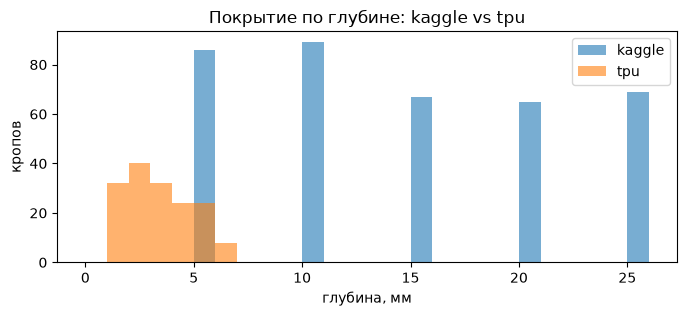

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([r[3] for r in IDX_KAGGLE], bins=np.arange(0, 27, 1), alpha=.6, label="kaggle")
ax.hist([r[3] for r in IDX_TPU], bins=np.arange(0, 27, 1), alpha=.6, label="tpu")
ax.set_xlabel("глубина, мм"); ax.set_ylabel("кропов"); ax.legend()
ax.set_title("Покрытие по глубине: kaggle vs tpu"); plt.show()

## Эксп. 1 — перенос kaggle → tpu

Проверяем: обучение на kaggle, тест на **всём** tpu (held-out домен). tpu-диапазон
для модели — экстраполяция вниз → базовая оценка переноса «в лоб».

In [8]:
out1 = run(IDX_KAGGLE, IDX_TPU, FEATS, model_name="resnet34", mode="p5+d1", optim="muon")
pd.DataFrame(out1["metrics"].by_domain()).T[["mae_mm", "rmse_mm", "r2", "bias_mm"]]

,mae_mm,rmse_mm,r2,bias_mm
tpu,9.950076,10.595867,-46.523342,9.950076
all,9.950076,10.595867,-46.523342,9.950076


In [ ]:
scatter_pred(out1["metrics"], "Эксп.1 — перенос kaggle→tpu")

## Эксп. 2 — смешанный трейн, раздельный тест

Проверяем: train = kaggle + часть tpu-видео; тест — held-out видео **каждого**
домена, метрики раздельно. Смешивание закрывает 0.5–25 мм → экстраполяция
становится интерполяцией.

In [10]:
combined = IDX_KAGGLE + IDX_TPU
train_idx, test_idx = split_by_video(combined, n_test=3, domains=["kaggle", "tpu"])
print("train кропов=%d  test кропов=%d" % (len(train_idx), len(test_idx)))
out2 = run(train_idx, test_idx, FEATS, model_name="resnet34", mode="p5+d1", optim="muon")
pd.DataFrame(out2["metrics"].by_domain()).T[["mae_mm", "rmse_mm", "r2", "bias_mm"]]

train кропов=492  test кропов=44


,mae_mm,rmse_mm,r2,bias_mm
kaggle,2.553067,4.820336,0.480042,-0.398931
tpu,2.006553,2.716836,-2.096030,1.111821
all,2.254969,3.819393,0.617181,0.425115


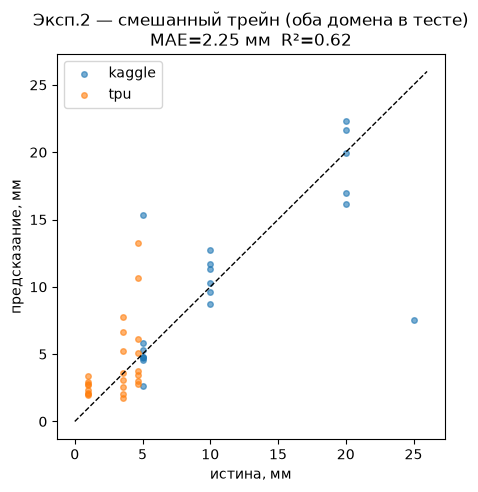

In [11]:
scatter_pred(out2["metrics"], "Эксп.2 — смешанный трейн (оба домена в тесте)")

## Эксп. 3 — k-fold по tpu-видео

Проверяем устойчивость оценки на tpu: 4 фолда по tpu-видео (kaggle всегда в трейне),
усреднённый MAE ± разброс вместо одиночного шумного теста.

fold 1: hold=5 видео | tpu MAE=1.32 мм
fold 2: hold=5 видео | tpu MAE=1.83 мм
fold 3: hold=5 видео | tpu MAE=1.71 мм
fold 4: hold=5 видео | tpu MAE=1.49 мм

k-fold tpu MAE: 1.59 ± 0.20 мм


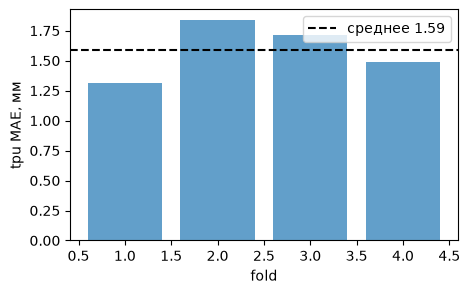

In [12]:
tpu_vids = list(np.random.default_rng(SEED).permutation(sorted({r[0] for r in IDX_TPU})))
K = 4
fold_mae = []
for fi in range(K):
    hold = set(tpu_vids[fi::K])
    tr = IDX_KAGGLE + [r for r in IDX_TPU if r[0] not in hold]
    te = [r for r in IDX_TPU if r[0] in hold]
    m = run(tr, te, FEATS, model_name="resnet34", mode="p5+d1", optim="muon")["metrics"].compute()
    fold_mae.append(m["mae_mm"])
    print(f"fold {fi + 1}: hold={len(hold)} видео | tpu MAE={m['mae_mm']:.2f} мм")
print(f"\nk-fold tpu MAE: {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f} мм")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(1, K + 1), fold_mae, alpha=.7)
ax.axhline(np.mean(fold_mae), color="k", ls="--", label=f"среднее {np.mean(fold_mae):.2f}")
ax.set_xlabel("fold"); ax.set_ylabel("tpu MAE, мм"); ax.legend(); plt.show()

## Эксп. 4 — оптимизатор: Adam vs Muon

Проверяем влияние оптимизатора на смешанном сетапе (Эксп.2). Muon ортогонализует
обновление скрытых весов — обычно заметно точнее Adam на этой задаче.

mae_mm  rmse_mm     r2
optim domain                        
adam  kaggle   2.608    4.520  0.543
      tpu      2.117    2.935 -2.614
      all      2.340    3.740  0.633
muon  kaggle   2.553    4.820  0.480
      tpu      2.007    2.717 -2.096
      all      2.255    3.819  0.617

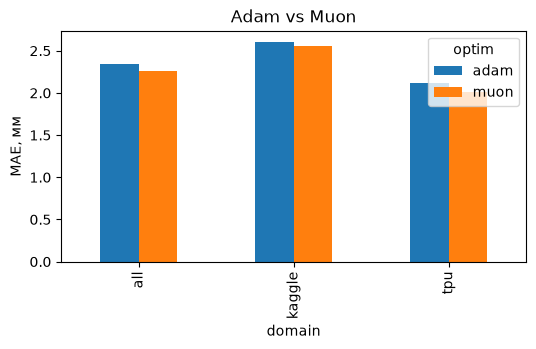

In [13]:
cmp = {opt: run(train_idx, test_idx, FEATS, "resnet34", "p5+d1", optim=opt)["metrics"].by_domain()
       for opt in ["adam", "muon"]}
df_opt = pd.DataFrame([{"optim": o, "domain": d, **{k: round(v, 3) for k, v in m.items()}}
                       for o, dd in cmp.items() for d, m in dd.items()]).set_index(["optim", "domain"])
display(df_opt[["mae_mm", "rmse_mm", "r2"]])

fig, ax = plt.subplots(figsize=(6, 3))
piv = df_opt.reset_index().pivot(index="domain", columns="optim", values="mae_mm")
piv.plot.bar(ax=ax); ax.set_ylabel("MAE, мм"); ax.set_title("Adam vs Muon"); plt.show()

## Эксп. 5 — аугментации on-the-fly

Проверяем, стабилизируют ли пространственные аугментации (flip/rot90 по кропу)
предсказание. Сравниваем метрики и per-video разброс (std по кропам видео).

In [14]:
cmp_aug = {("aug" if f else "no_aug"): run(train_idx, test_idx, FEATS, "resnet34", "p5+d1",
                                          optim="muon", augment=f) for f in (False, True)}
df_aug = pd.DataFrame([{"aug": k, "domain": d, **{m: round(v, 3) for m, v in md_.items()}}
                       for k, res in cmp_aug.items() for d, md_ in res["metrics"].by_domain().items()])
df_aug.set_index(["aug", "domain"])[["mae_mm", "rmse_mm", "r2"]]

mae_mm  rmse_mm     r2
aug    domain                        
no_aug kaggle   2.553    4.820  0.480
       tpu      2.007    2.717 -2.096
       all      2.255    3.819  0.617
aug    kaggle   1.845    3.319  0.753
       tpu      1.478    2.024 -0.718
       all      1.645    2.691  0.810

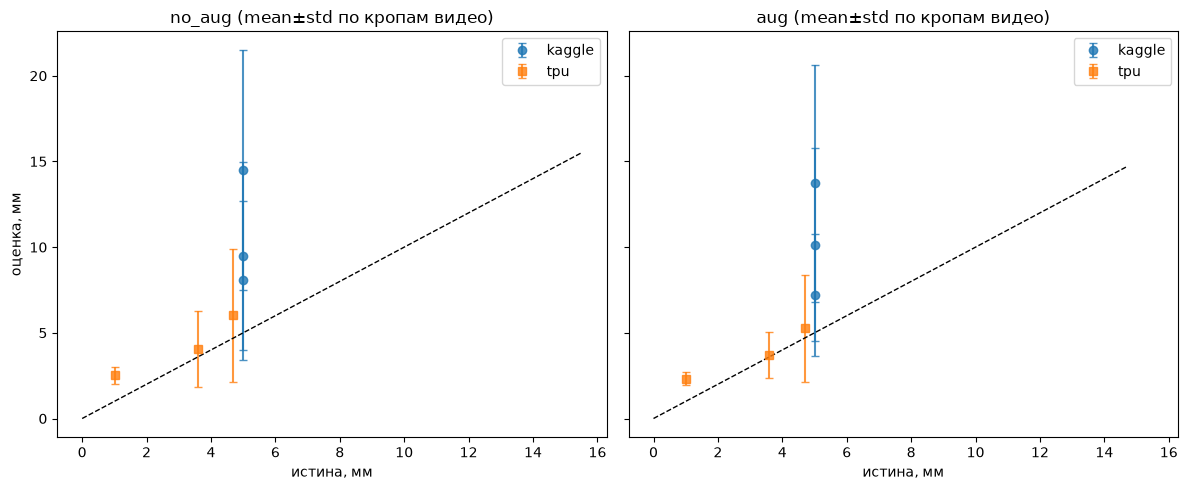

In [15]:
def per_video(res):
    rm = res["metrics"]
    df = pd.DataFrame({"vid": [r[0] for r in test_idx], "domain": [r[4] for r in test_idx],
                       "true": rm.y_true, "pred": rm.y_pred})
    return df.groupby(["domain", "vid"]).agg(true=("true", "first"),
            pm=("pred", "mean"), ps=("pred", "std")).reset_index()

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, key in zip(axs, ["no_aug", "aug"]):
    g = per_video(cmp_aug[key])
    for d, mk in [("kaggle", "o"), ("tpu", "s")]:
        s = g[g.domain == d]
        ax.errorbar(s.true, s.pm, yerr=s.ps, fmt=mk, capsize=3, alpha=.8, label=d)
    hi = max(g.true.max(), g.pm.max()) + 1
    ax.plot([0, hi], [0, hi], "k--", lw=1)
    ax.set_title(f"{key} (mean±std по кропам видео)"); ax.set_xlabel("истина, мм"); ax.legend()
axs[0].set_ylabel("оценка, мм"); plt.tight_layout(); plt.show()

## Эксп. 6 — сетка: модель × каналы × эпохи

Проверяем чувствительность к архитектуре, набору каналов (p5 vs p5+d1) и бюджету
обучения. Оптимизатор — Muon (рабочий режим по Эксп.4).

In [16]:
import itertools
grid = list(itertools.product(["resnet34", "convnext_nano"], ["p5", "p5+d1"], [30, 50]))
rows, gm = [], {}
for model_name, mode, ep in grid:
    key = f"{model_name}|{mode}|{ep}ep"
    print("##", key)
    rm = run(train_idx, test_idx, FEATS, model_name, mode, epochs=ep, optim="muon")["metrics"]
    gm[key] = rm
    for dom, m in rm.by_domain().items():
        rows.append({"model": model_name, "mode": mode, "epochs": ep, "domain": dom,
                     **{k: round(v, 3) for k, v in m.items()}})
grid_df = pd.DataFrame(rows)
grid_df.set_index(["model", "mode", "epochs", "domain"])[["mae_mm", "rmse_mm", "r2"]]

## resnet34|p5|30ep
## resnet34|p5|50ep
## resnet34|p5+d1|30ep
## resnet34|p5+d1|50ep
## convnext_nano|p5|30ep
## convnext_nano|p5|50ep
## convnext_nano|p5+d1|30ep
## convnext_nano|p5+d1|50ep


mae_mm  rmse_mm     r2
model         mode  epochs domain                        
resnet34      p5    30     kaggle   2.309    4.236  0.598
                           tpu      1.611    2.156 -0.949
                           all      1.928    3.270  0.719
                    50     kaggle   2.106    4.045  0.634
                           tpu      1.560    2.132 -0.906
                           all      1.808    3.149  0.740
              p5+d1 30     kaggle   2.553    4.820  0.480
                           tpu      2.007    2.717 -2.096
                           all      2.255    3.819  0.617
                    50     kaggle   2.279    4.420  0.563
                           tpu      1.697    2.442 -1.501
                           all      1.961    3.483  0.682
convnext_nano p5    30     kaggle   1.672    3.644  0.703
                           tpu      1.662    3.146 -3.152
                           all      1.666    3.382  0.700
                    50     kaggle   1.673    3.395  0.742
                           tpu      1.609    2.982 -2.731
                           all      1.638    3.177  0.735
              p5+d1 30     kaggle   1.674    3.237  0.766
                           tpu      1.708    3.038 -2.871
                           all      1.693    3.130  0.743
                    50     kaggle   1.713    3.305  0.756
                           tpu      1.727    3.109 -3.056
                           all      1.721    3.200  0.731

,model,mode,epochs,mae_mm,rmse_mm
0,resnet34,p5,50,1.560,2.132
1,convnext_nano,p5,50,1.609,2.982
2,resnet34,p5,30,1.611,2.156
3,convnext_nano,p5,30,1.662,3.146
4,resnet34,p5+d1,50,1.697,2.442
5,convnext_nano,p5+d1,30,1.708,3.038
6,convnext_nano,p5+d1,50,1.727,3.109
7,resnet34,p5+d1,30,2.007,2.717


TypeError: can only concatenate str (not "method") to str

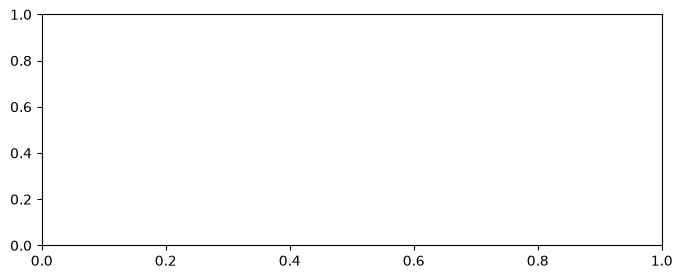

In [17]:
# лучшие по tpu MAE (основная метрика на непокрытом диапазоне)
best = (grid_df[grid_df.domain == "tpu"].sort_values("mae_mm")
        [["model", "mode", "epochs", "mae_mm", "rmse_mm"]].reset_index(drop=True))
display(best)
fig, ax = plt.subplots(figsize=(8, 3))
lbl = grid_df[grid_df.domain == "tpu"].assign(cfg=lambda d: d.model + "|" + d.mode + "|" + d.epochs.astype(str))
ax.bar(lbl.cfg, lbl.mae_mm, alpha=.7); ax.set_ylabel("tpu MAE, мм")
ax.tick_params(axis="x", rotation=60); ax.set_title("Сетка — tpu MAE по конфигу"); plt.show()

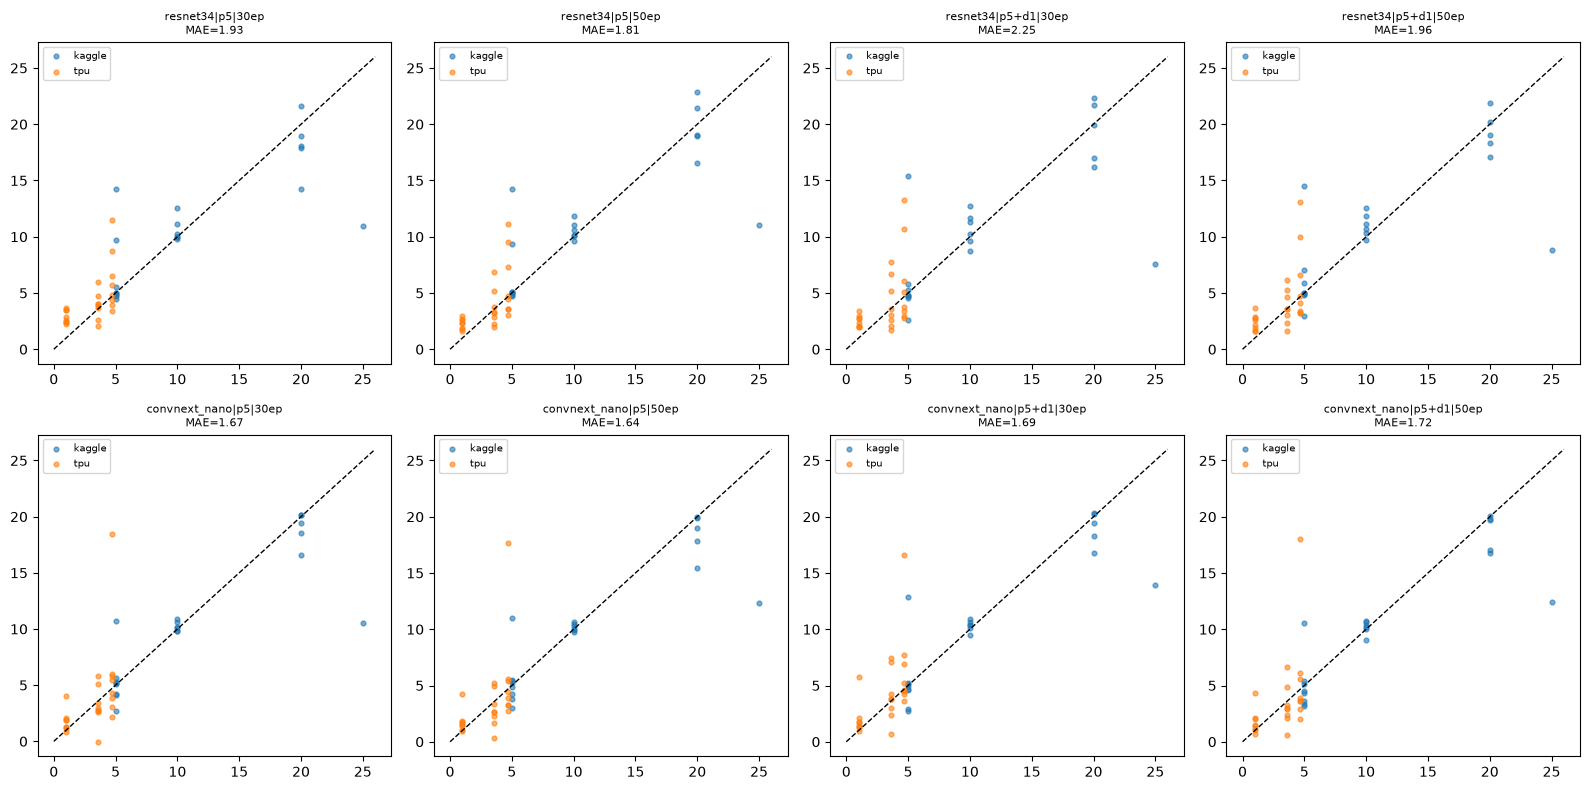

In [18]:
# pred vs true по всем конфигурациям сетки
n = len(gm); ncol = 4; nrow = (n + ncol - 1) // ncol
fig, axs = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
axs = np.atleast_1d(axs).ravel()
dom = np.array([r[4] for r in test_idx])
for ax, (key, rm) in zip(axs, gm.items()):
    for d, c in [("kaggle", "tab:blue"), ("tpu", "tab:orange")]:
        m = dom == d
        ax.scatter(rm.y_true[m], rm.y_pred[m], s=12, alpha=.6, color=c, label=d)
    hi = max(rm.y_true.max(), rm.y_pred.max()) + 1
    ax.plot([0, hi], [0, hi], "k--", lw=1)
    ax.set_title(f"{key}\nMAE={rm.compute()['mae_mm']:.2f}", fontsize=8)
    ax.legend(fontsize=7)
for ax in axs[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Итог — оценённые глубины по видео (Эксп.2)

Агрегируем предсказания по видео: истина, среднее ± разброс кропов, ошибка.

,domain,vid,true_mm,pred_mean,pred_std,n,err_mm
0,kaggle,R_020,5.000000,14.52,7.00,6,9.52
1,kaggle,Z_004,5.000000,9.48,5.47,12,4.48
2,kaggle,Z_011,5.000000,8.05,4.64,2,3.05
3,tpu,Sample_3_Static,1.004706,2.53,0.50,8,1.52
4,tpu,Sample_4_Static,3.588235,4.08,2.21,8,0.49
5,tpu,Sample_8_Static,4.688627,6.01,3.90,8,1.32


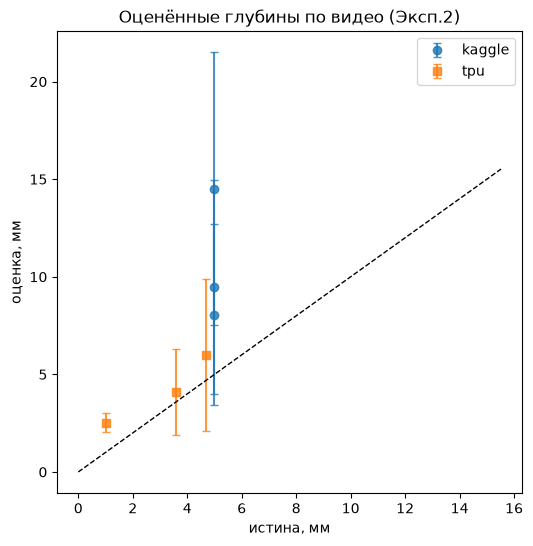

In [19]:
rm = out2["metrics"]
df = pd.DataFrame({"vid": [r[0] for r in test_idx], "domain": [r[4] for r in test_idx],
                   "true_mm": rm.y_true, "pred_mm": rm.y_pred})
g = (df.groupby(["domain", "vid"]).agg(true_mm=("true_mm", "first"),
        pred_mean=("pred_mm", "mean"), pred_std=("pred_mm", "std"), n=("pred_mm", "size"))
     .reset_index())
g["err_mm"] = (g.pred_mean - g.true_mm).round(2)
g[["pred_mean", "pred_std"]] = g[["pred_mean", "pred_std"]].round(2)
display(g.sort_values(["domain", "true_mm"]))

fig, ax = plt.subplots(figsize=(6, 6))
for d, mk in [("kaggle", "o"), ("tpu", "s")]:
    s = g[g.domain == d]
    ax.errorbar(s.true_mm, s.pred_mean, yerr=s.pred_std, fmt=mk, capsize=3, alpha=.8, label=d)
hi = max(g.true_mm.max(), g.pred_mean.max()) + 1
ax.plot([0, hi], [0, hi], "k--", lw=1)
ax.set_xlabel("истина, мм"); ax.set_ylabel("оценка, мм"); ax.legend()
ax.set_title("Оценённые глубины по видео (Эксп.2)"); plt.show()